# Predikcija unapredjenja zaposlenih primenom tehnika masinskog ucenja

Cilj projekta je primena masinskog ucenja za predvidjanje unapredjenja zaposlenih na osnovu njihovih demografskih i profesionalnih karakteristika. Problem je formulisan kao zadatak binarne klasifikacije, gde ciljno obelezje oznacava da li je zaposleni unapredjen ili ne. Primenom tehnika masinskog ucenja nastojimo da otkrijemo obrasce u podacima i identifikujemo kljucne faktore koji uticu na unapredjenje. 

In [55]:
# %pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

### Koriscene biblioteke

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

%matplotlib inline

## Ucitavanje i opis podataka 

Ucitavanje podataka i prikaz osnovnih informacija

In [57]:
df = pd.read_csv('data/train.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


Skup podataka cini 54808 zapisa sa 13 atributa i sadrzi demografske i profesionalne informacije o zaposlenima, kao i ciljno obelezje `is_promoted` koje oznacava da li je zaposleni unapredjen. Prisutan je veci broj numerickih i kategorijskih atributa, sto zahteva odgovarajuce pretprocesiranje pre primene modela masinskog ucenja.

### Kvalitet podataka
Pre dalje analize i modelovanja, neophodno je proveriti kvalitet podataka, ukljucujuci prisustvo nedostajucih vrednosti i eventualnih duplikata.

In [58]:
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(0)

Primetno je prisustvo nedostajucih vrednosti atributa `education` i `previous_year_rating`, sto zahteva primenu odgovarajucih tehnika imputacije u fazi pretprocesiranja. Skup podataka ne sadrzi duplikate.

### Analiza ciljne promenljive
U ovoj sekciji se nalazi analiza raspodele ciljne promenljive `is_promoted`. Razumevanje odnosa izmedju klasa je kljucno za izbor odgovarajucih tehnika balansiranja podataka i evaluacije modela.

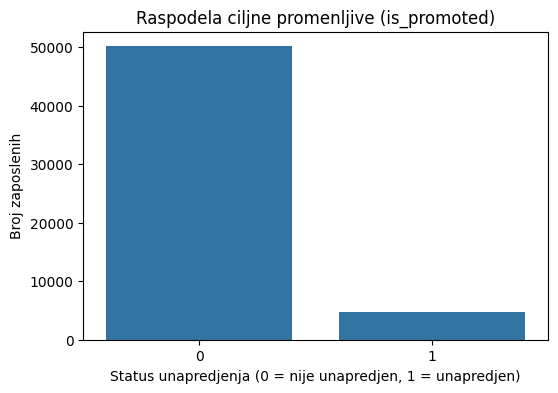

is_promoted
0    91.482995
1     8.517005
Name: proportion, dtype: float64

In [60]:
plt.figure(figsize=(6, 4))
sns.countplot(x="is_promoted", data=df)
plt.title("Raspodela ciljne promenljive (is_promoted)")
plt.xlabel("Status unapredjenja (0 = nije unapredjen, 1 = unapredjen)")
plt.ylabel("Broj zaposlenih")
plt.show()
df['is_promoted'].value_counts(normalize=True) * 100

Analiza raspodele ciljne promenljive pokazuje izrazenu nebalansiranost klasa, pri cemu znatno veci broj zaposlenih nije unapredjen u odnosu na one koji jesu. Ovakva struktura podataka moze dovesti do toga da modeli favorizuju vecinsku klasu.
Zbog toga ce u nastavku rada biti primenjena SMOTE tehnika za balansiranje podataka iskljucivo nad trening skupom, dok ce se kao glavna metrika za evaluaciju performansi koristiti F1-score, koji daje uravnotezenu meru izmedju preciznosti i odziva i omogucava realniju procenu performansi modela u ovakvim uslovima.

## Eksplorativna analiza relevantnih atributa
U ovoj sekciji je prikazana analiza atributa za koje se na osnovu domenskog znanja i preliminarne analize, može ocekivati da imaju znacajan uticaj na unapredjenje zaposlenih. Cilj ove analize je identifikacija potencijalno relevantnih faktora za dalje modelovanje.

## Uticaj profesionalnih atributa 

### Prethodna ocena rada

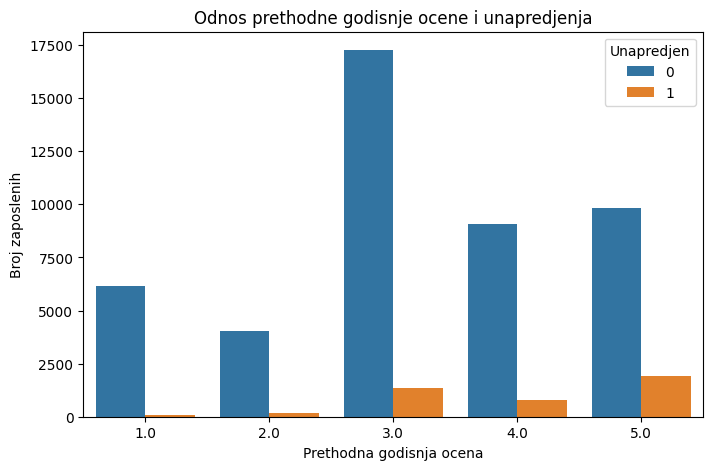

In [61]:
plt.figure(figsize=(8, 5))
sns.countplot(x="previous_year_rating", hue="is_promoted", data=df)
plt.title("Odnos prethodne godisnje ocene i unapredjenja")
plt.xlabel("Prethodna godisnja ocena")
plt.ylabel("Broj zaposlenih")
plt.legend(title="Unapredjen")
plt.show()

Uocava se jasna povezanost izmedju vise prethodne godisnje ocene i vece verovatnoce unapredjenja, sto ukazuje da je ovaj atribut jedan od kljucnih faktora u procesu donosenja odluka o unapredjenju.

### Rezultat obuke

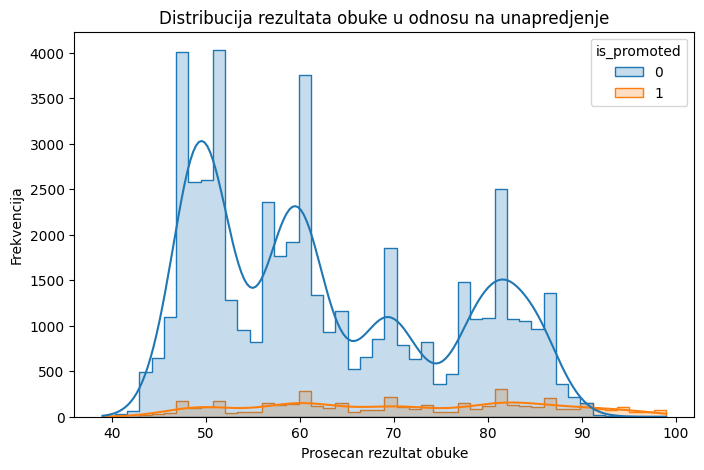

In [62]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="avg_training_score", hue="is_promoted", kde=True, element="step")
plt.title("Distribucija rezultata obuke u odnosu na unapredjenje")
plt.xlabel("Prosecan rezultat obuke")
plt.ylabel("Frekvencija")
plt.show()

Zaposleni sa visim rezultatima obuka imaju vecu ucestalost unapredjenja, sto potvrdjuje znacaj kontinuiranog usavrsavanja u procesu napredovanja.

### Nagrade

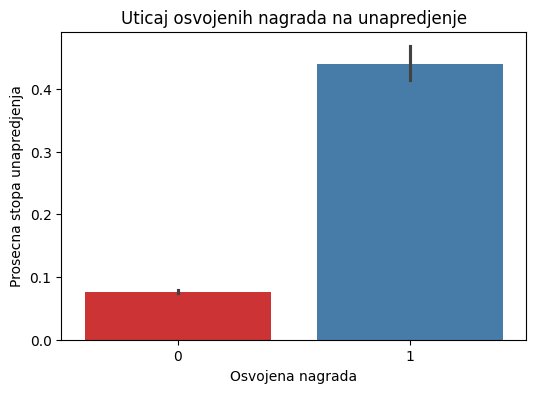

In [63]:
plt.figure(figsize=(6, 4))
sns.barplot(x="awards_won?", y="is_promoted", data=df, hue="awards_won?", palette="Set1", legend=False)
plt.title("Uticaj osvojenih nagrada na unapredjenje")
plt.xlabel("Osvojena nagrada")
plt.ylabel("Prosecna stopa unapredjenja")
plt.show()

Zaposleni koji su osvojili nagrade imaju znatno vecu prosecnu stopu unapredjenja, sto ukazuje na snazan pozitivan uticaj ovog atributa.

### Godine radnog staza

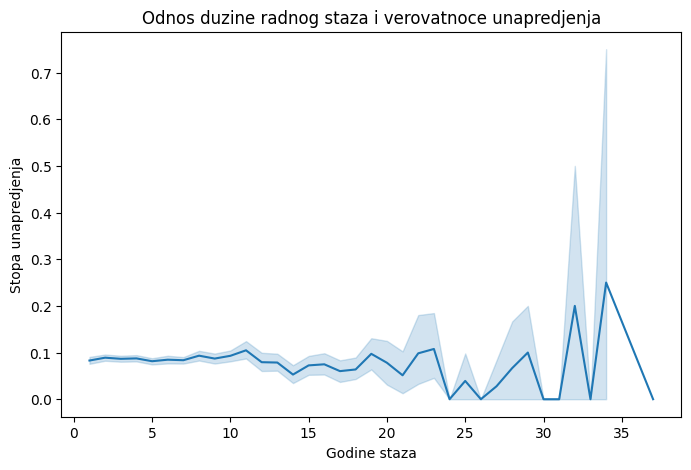

In [64]:
plt.figure(figsize=(8, 5))
sns.lineplot(x="length_of_service", y="is_promoted", data=df)
plt.title("Odnos duzine radnog staza i verovatnoce unapredjenja")
plt.xlabel("Godine staza")
plt.ylabel("Stopa unapredjenja")
plt.show()

Verovatnoca unapredjenja raste sa godinama staza do odredjene tacke, nakon cega se stabilizuje, sto ukazuje na nelinearnu zavisnost ovog atributa.

Na osnovu selektivne eksplorativne analize moze se zakljuciti da atributi kao sto su prethodna godisnja ocena, rezultati obuka, osvojene nagrade i duzina radnog staza imaju znacajan uticaj na verovatnocu unapredjenja.

## Demografski faktori

### Starost

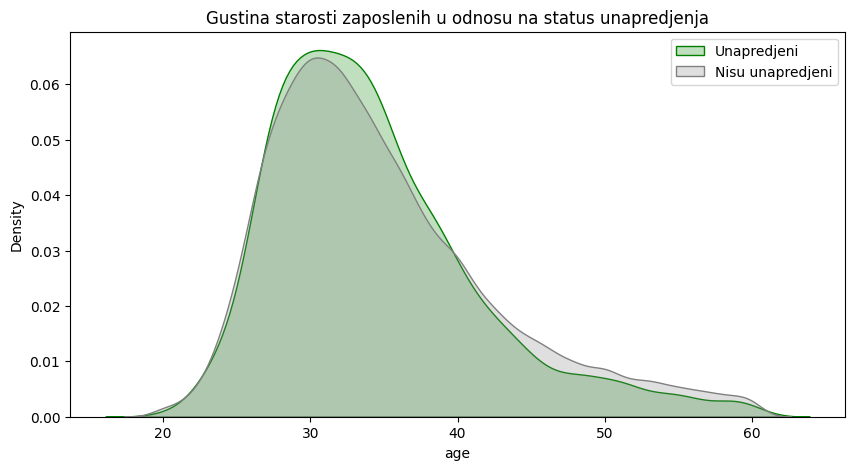

In [65]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['is_promoted'] == 1], x='age', label='Unapredjeni', fill=True, color='green')
sns.kdeplot(data=df[df['is_promoted'] == 0], x='age', label='Nisu unapredjeni', fill=True, color='grey')
plt.title('Gustina starosti zaposlenih u odnosu na status unapredjenja')
plt.legend()
plt.show()

### Pol

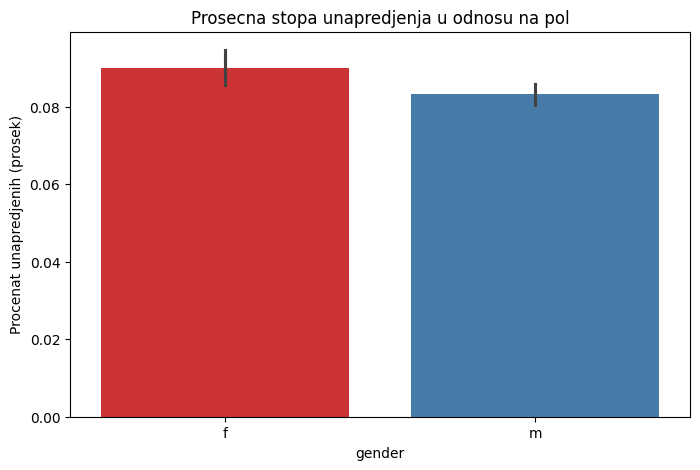

In [66]:
plt.figure(figsize=(8,5))
sns.barplot(x='gender', y='is_promoted', data=df, hue='gender', palette='Set1', legend=False)
plt.title('Prosecna stopa unapredjenja u odnosu na pol')
plt.ylabel('Procenat unapredjenih (prosek)')
plt.show()

### Obrazovanje

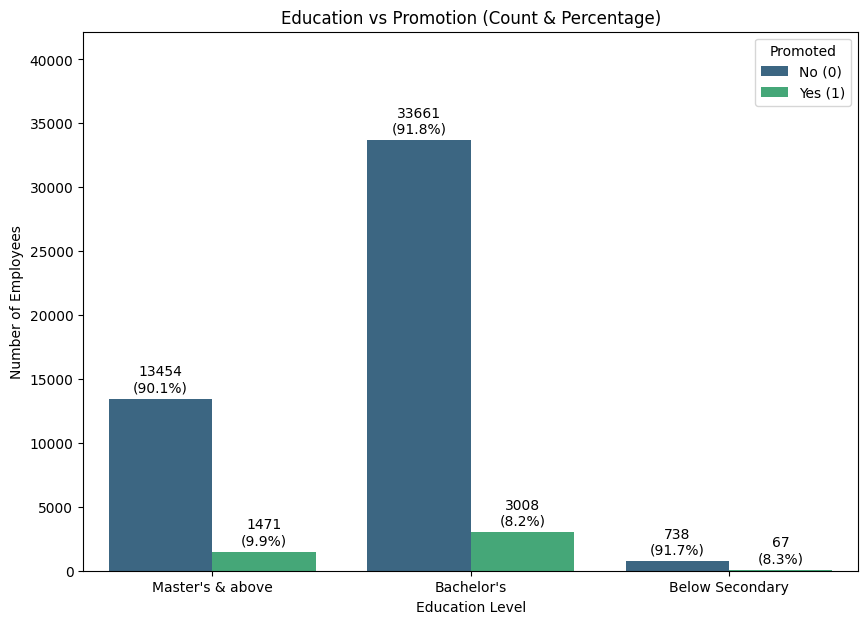

In [67]:
plt.figure(figsize=(10, 7))
ax = sns.countplot(x="education", hue="is_promoted", data=df, palette='viridis')

total_per_edu = df.groupby('education').size()
edu_order = [label.get_text() for label in ax.get_xticklabels()]

for container in ax.containers:
    labels = []
    for i, v in enumerate(container):
        count = v.get_height()
        if count > 0:
            edu_name = edu_order[i]
            total = total_per_edu[edu_name]
            percentage = (count / total) * 100
            labels.append(f'{int(count)}\n({percentage:.1f}%)')
        else:
            labels.append('0 (0.0%)')
    
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title("Education vs Promotion (Count & Percentage)")
plt.xlabel("Education Level")
plt.ylabel("Number of Employees")
plt.legend(title='Promoted', labels=['No (0)', 'Yes (1)'])
plt.ylim(0, df['education'].value_counts().max() * 1.15)
plt.show()

Analiza demografskih atributa ukazuje da starost, nivo obrazovanja i pol pokazuju odredjene razlike u stopama unapredjenja, ali bez izrazitih diskontinuiteta izmedju grupa. U poredjenju sa profesionalnim atributima, njihov uticaj deluje slabije izrazen. Iz tog razloga, demografski faktori ce biti ukljuceni u dalje modelovanje, ali se ne ocekuje da imaju dominantan doprinos u predikciji unaprecjenja.

---

# Pretprocesiranje podataka

## Definisanje ulaznih i izlazne promenljive

Cilj modela je predvidjanje da li je zaposleni unapredjen, sto predstavlja vrednost ciljne promenljive `is_promoted`. Svi ostali atributi predstavljaju ulazne promenljive na osnovu kojih modeli uce obrasce.

Pre pretprocesiranja se vrsi razdvajanje ulaza i izlaza da bi se izbeglo nenamerno koriscenje ciljne promenljive u imputaciji i transformacijama i da bi se omogucila pravilna primena tehnika kao sto su SMOTE i skaliranje iskljucivo nad ulazima.

In [68]:
X = df.drop('is_promoted', axis=1)
y = df['is_promoted']

Na ovaj nacin su razdvojeni podaci koje modeli koriste za ucenje (`X`) i tacni odgovori (`y`), sto je neophodno za ispravno treniranje i evaluaciju modela.

## Uklanjanje neinformativnih atributa

Kolona `employee_id` predstavlja jedinstveni identifikator zaposlenog i ne sadrzi informaciju relevantnu za proces unapredjenja. Njeno zadrzavanje moze dovesti do laznih obrazaca, pa se uklanja iz daljeg razmatranja.

In [69]:
X = X.drop('employee_id', axis=1)

Uklanjanjem identifikatora sprecava se da modeli uce irelevantne ili slucajne obrasce.

## Podela podataka na trening i test skup

Podaci se dele u odnosu 70:30, pri cemu se:
- trening skup koristi za ucenje i optimizaciju modela,
- test skup cuva netaknut za konacnu evaluaciju.

Stratifikacija po ciljnoj promenljivoj se koristi zbog izrazene klasne neravnoteze.

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [71]:
# dimenzije podataka pre imputacije, test ostaje nepromenjen
print("X_train_res shape:", X_train.shape)
print("y_train_res shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train_res shape: (38365, 11)
y_train_res shape: (38365,)
X_test shape: (16443, 11)
y_test shape: (16443,)


Ovim pristupom obezbedjena je objektivna procena performansi modela.

## Razdvajanje numerickih i kategorijskih atributa

Razlicite vrste atributa zahtevaju razlicite tehnike pretprocesiranja:
- numericki atributi zahtevaju imputaciju i skaliranje,
- kategorijski atributi zahtevaju imputaciju i kodiranje.

Zbog toga se atributi razdvajaju po tipu.

In [72]:
num_cols = [
    'age',
    'no_of_trainings',
    'previous_year_rating',
    'length_of_service',
    'avg_training_score',
    'awards_won?'
]

cat_cols = [
    'department',
    'region',
    'education',
    'gender',
    'recruitment_channel'
]

Ova podela omogucava obradu podataka uskladjenu sa tipom.

## Imputacija nedostajucih vrednosti

S obzirom na umeren procenat nedostajucih vrednosti, podaci nisu uklanjani.
Primenjena je kontrolisana imputacija:
- numericke vrednosti zamenjuju se medianom,
- kategorijske vrednosti se zamenjuju novom kategorijom 'Unknown'.

In [73]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

Upotrebom metoda fit_transform() na trening skupom i transform() nad test skupom odradjena je imputacija nedostajucih vrednosti, a ovaj pristup sprecava curenje informacija iz test skupa.

## Kodiranje kategorijskih atributa

Za kodiranje kategorijskih atributa promenjena je One-Hot Encoding metoda, pri cemu se svaka kategorija transformise u binarnu promenjivu, cime se izbegava uvodjenje vestackog redosleda izmedju kategorija, sto je vazno za modele koji pretpostavljaju linearnu zavisnost izmedju ulaznih promenjivih i ciljne promenjive kao sto radi logisticka regresija..

In [74]:
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

Nakon kodiranja uradjeno je uskladjivanje trening i test skupa kako bi oba skupa imala identicnu strukturu kolona, zbog omogucavanja konzistentnosti ulaznih podataka tokom treninga i evaluacije.

## Skaliranje numerickih atributa

Skaliranje se primenjuje zbog logisticke regresije, koja je osetljiva na razlicite razmere atributa. Za modele zasnovane na stablima skaliranje nije neophodno, ali se zadrzava radi konzistentnosti.

In [75]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Skalirani podaci omogucavaju stabilnije i uporedive rezultate modela.

## Balansiranje klasa primenom SMOTE tehnike

Primena SMOTE tehnike za balansiranje podataka kako bi modeli mogli da nauce obrasce unapredjenja bez pristrasnosti ka vecinskoj klasi.
Zbog izrazene klasne neravnoteze, SMOTE tehnika se primenjuje iskljucivo nad trening skupom kako bi se sprecilo curenje informacija iz test skupa.

In [76]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

Na ovaj nacin modeli dobijaju uravnotezen trening skup, dok test skup ostaje nepromenjen.

### Provera dimenzija podataka nakon pretprocesiranja

In [77]:
print("X_train_res shape:", X_train_res.shape)
print("y_train_res shape:", y_train_res.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train_res shape: (70194, 53)
y_train_res shape: (70194,)
X_test shape: (16443, 53)
y_test shape: (16443,)


Broj redova u trening skupu je povecan zbog primene SMOTE tehnike, dok je test skup ostao nepromenjen da bi se zadrzala distribucija klasa.

### Provera balansiranosti klasa u trening skupu

Provera raspodela ciljnih klasa u trening skupu nakon primene SMOTE tehnike.

In [78]:
pd.Series(y_train_res).value_counts(normalize=True) * 100

is_promoted
0    50.0
1    50.0
Name: proportion, dtype: float64

Trening skup je balansiran.

### Provera da nema nedostajucih vrednosti

In [79]:
print("Nedostajuce vrednosti u X_train_res:", X_train_res.isnull().sum().sum())
print("Nedostajuce vrednosti u X_test:", X_test.isnull().sum().sum())

Nedostajuce vrednosti u X_train_res: 0
Nedostajuce vrednosti u X_test: 0


## Uvid u konacni izgled podataka

Prikaz nekoliko prvih redova trening skupa koji predstavlja konacni format podataka koje modeli koriste za ucenje.

In [80]:
X_train_res.head()

,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,department_Finance,department_HR,department_Legal,department_Operations,...,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,education_Unknown,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
0,-0.416218,-1.017475,-0.253348,-0.437284,-0.153041,-0.850984,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,1.234584,0.414760,0.569448,0.973880,-0.153041,1.169258,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-0.416218,-1.147679,-1.898941,-0.672478,-0.153041,-0.476865,False,False,False,True,...,False,False,False,False,False,False,False,True,False,True
3,-0.416218,-1.017475,-1.076144,-0.437284,-0.153041,-1.075455,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,-0.416218,-0.887272,-0.253348,-0.907672,-0.153041,0.196549,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


### Zakljucak pretprocesiranja podataka

U ovoj fazi podaci su pripremljeni za primenu algoritama masinskog ucenja na nacin koji obezbedjuje pouzdanost i objektivnost rezultata.

Izvrseno je razdvajanje ulaznih i izlazne promenljive, uklanjanje neinformativnih atributa, kao i imputacija nedostajucih vrednosti bez gubitka podataka. Kategorijski atributi su kodirani primenom One-Hot Encoding metode, dok su numericki atributi skalirani radi stabilnijeg
ponasanja modela. Zbog izrazene klasne neravnoteze, nad trening skupom je primenjena SMOTE tehnika, dok je test skup ostao neizmenjen kako bi se obezbedila realna procena performansi modela.

Na kraju ove faze imamo skupove:
- `X_train_res` koji sadrzi pretprocesirane i balansirane ulaze potrebne za treniranje modela
- `y_train_res` koji sadrzi ciljnu klasu i potreban je za svrhu ucenja; u trening skupu je izbalansirano prisustvo ciljne promenjive
- `X_test` koji sadrzi pretprocesirane ulaze, potreban za evaluaciju
- `y_test` koji sadrzi prava resenja, potreban za evaluaciju

---

## Logisticka regresija - bazni model

Logisticka regresija se koristi kao bazni model za problem binarne klasifikacije unapredjenja zaposlenih.
U kontekstu ovog rada bazni model sluzi za postavljanje referentne tacke performansi i poredjenje sa slozenijim nelinearnim modelima.

Model se trenira na prethodno balansiranom trening skupu.

In [81]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_res, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Evaluacija baznog modela

Evaluacija modela se vrsi na originalnom test skupu koji zadrzava realnu distribuciju klasa od oko 9% unapredjenih zaposlenih. Zbog klasne neravnoteze, kao glavna metrika koristi se F1-score, uz prikaz preciznosti i odziva.

In [82]:
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression\n")
print("F1-score:", f1_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression

F1-score: 0.36069474185105876

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.86      0.91     15043
           1       0.27      0.54      0.36      1400

    accuracy                           0.84     16443
   macro avg       0.61      0.70      0.63     16443
weighted avg       0.89      0.84      0.86     16443



Na osnovu rezultata odziva baznog modela od 0.54 mozemo zakljuciti da model uspeva da identifikuje vise od pola stvarno unapredjenih, ali uz nisku preciznost od 0.27 sto predstavlja veliki broj lazno pozitivnih. Tacnost od 0.84 je neadekvatna mera performansi modela zbog neravnomerne raspodele klasa, te se f1-score koristi kao primarna metrika evaluacije i ovde iznosi 0.36.

## Random Forest

Random Forest je ansambl metoda zasnovana na stablima odlucivanja, koja je pogodna za modelovanje nelinearnih odnosa izmedju promenjivih i zbog svoje robusnosti protiv overfitting-a. 

Model se trenira na prethodno balansiranom trening skupu.

In [83]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Evaluacija Random Forest modela 

Evaluacija se vrsi na originalnom test skupu, gde je ocuvana realna distribucija klasa.

In [84]:
y_pred_rf = rf.predict(X_test)

print("Random Forest\n")
print("F1-score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest

F1-score: 0.4121110176619008

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.97      0.95     15043
           1       0.50      0.35      0.41      1400

    accuracy                           0.91     16443
   macro avg       0.72      0.66      0.68     16443
weighted avg       0.90      0.91      0.91     16443



Odziv od 0.35 ukazuje da model identifikuje oko trecinu stvarno unapredjenih zaposlenih, sto je nize od odziva Logisticke Regresije gde je odziv iznosio 0.54, ali preciznost od 0.50 pokazuje da su predikcije pozitivne klase znatno pouzdanije u odnosu na logisticku regresiju, gde je ova vrednost iznosila 0.27. Zbog nebalansiranosti klasa visoka tacnost od 0.91 ne predstavlja adekvatnu meru uspesnosti modela, zbog cega je f1-score primarna metrika evaluacije.
f1-score sa vrednoscu od 0.41 predstavlja poboljsanje u poredjenju sa logistickom regresijom gde je f1-score iznosio 0.36, sto ukazuje da su performanse izmadju preciznosti i odziva bolje balansirane.



Moze se zakljuciti da Random Forest postize stabilnije i pouzdanije performanse u identifikaciji unapredjenih zaposlenih u odnosu na linearni model, sto je bilo ocekivano zbog njegove sposobnosti da modeluje nelinearne odnose izmadju promenjivih.